In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import ast

from pathlib import Path

In [4]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary_CLEAN_260728.csv'

df = pd.read_csv(file_path)

# Relationships between different levels

In [5]:
def parse_set(s):
    if pd.isna(s):
        return []
    try:
        return sorted(ast.literal_eval(s))
    except Exception:
        return [x.strip(" '\"") for x in s.strip('{}').split(',') if x.strip()]
 
df['level_list'] = df['level'].apply(parse_set)
LEVEL_ORDER = ['Beginner', 'Novice', 'Intermediate', 'Advanced']

In [6]:
df.head()

,title,description,level,goal,equipment,program_length_weeks,time_per_workout,total_exercises,program_length_days,average_intensity,level_list
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Advanced', 'Intermediate', 'Beginner', 'Novi...","{'Powerbuilding', 'Bodybuilding'}",Full Gym,7,90,140,35,8.40,"[Advanced, Beginner, Intermediate, Novice]"
1,Rampage,Pack on muscle and gain strength through this ...,"{'Advanced', 'Intermediate'}","{'Powerbuilding', 'Bodybuilding'}",Full Gym,18,70,558,108,8.51,"[Advanced, Intermediate]"
2,Fitness King Powerbuild 101,To gain strength while building aesthetic musc...,"{'Advanced', 'Intermediate'}","{'Powerbuilding', 'Bodybuilding'}",Full Gym,11,160,324,56,7.62,"[Advanced, Intermediate]"
3,Larry's Modified Bullmastiff Powerbuilding Pro...,All credit to Alex. You can find his original ...,"{'Intermediate', 'Beginner', 'Novice'}","{'Muscle & Sculpting', 'Powerlifting', 'Powerb...",Full Gym,9,70,342,54,7.30,"[Beginner, Intermediate, Novice]"
4,Metallicdpas PPL (Reddit),"Metallicdpas’ PPL targeted towards beginners, ...","{'Intermediate', 'Beginner', 'Novice'}","{'Muscle & Sculpting', 'Bodybuilding', 'Athlet...",Garage Gym,6,60,216,36,7.72,"[Beginner, Intermediate, Novice]"


In [7]:
# ---- 1. long table: one row per (program, level) ----
long = (
    df[['level_list']]
    .reset_index()                      # keep original row id as the join key
    .rename(columns={'index': 'program_id'})
    .explode('level_list')
    .rename(columns={'level_list': 'level'})
)

In [8]:
long

,program_id,level
0,0,Advanced
0,0,Beginner
0,0,Intermediate
0,0,Novice
1,1,Advanced
...,...,...
1357,1357,Novice
1358,1358,Advanced
1358,1358,Intermediate
1359,1359,Advanced


In [11]:
# ---- 2. self-join on program_id: every level a program has, paired with every level it has (incl. itself) ----
pairs = long.merge(long, on='program_id', suffixes=('_a', '_b'))

In [12]:
pairs

,program_id,level_a,level_b
0,0,Advanced,Advanced
1,0,Advanced,Beginner
2,0,Advanced,Intermediate
3,0,Advanced,Novice
4,0,Beginner,Advanced
...,...,...,...
10167,1358,Intermediate,Intermediate
10168,1359,Advanced,Advanced
10169,1359,Advanced,Intermediate
10170,1359,Intermediate,Advanced


In [13]:
# ---- 3. count occurrences of each (level_a, level_b) pair -> pivot into a matrix ----
matrix = (
    pd.crosstab(pairs['level_a'], pairs['level_b'])
    .reindex(index=LEVEL_ORDER, columns=LEVEL_ORDER)
    .fillna(0).astype(int)
)

In [14]:
matrix

level_b,Beginner,Novice,Intermediate,Advanced
level_a,,,,
Beginner,601,570,514,310
Novice,570,967,865,468
Intermediate,514,865,1196,641
Advanced,310,468,641,672


In [21]:
N_PROGRAMS = len(df)

In [22]:
pct_matrix = matrix / N_PROGRAMS * 100

In [16]:
print('single-level programs (no co-occurrence at all):', (df['level_list'].str.len() == 1).sum())
 

single-level programs (no co-occurrence at all): 266


In [23]:
# ---- plot: mask the upper triangle since the matrix is symmetric ----
BLUE_SEQ = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
            '#3987e5','#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']
blue_cmap = mcolors.LinearSegmentedColormap.from_list('blue_seq', BLUE_SEQ)
INK, INK_SECONDARY, INK_MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
TEXT_LIGHT = '#ffffff'
 
sns.set_theme(style='white', rc={
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK_SECONDARY,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED, 'font.family': 'sans-serif',
})

In [18]:
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)  # hide the mirrored upper half, keep the diagonal

In [27]:
annot = pct_matrix.round(1).astype(str) + '%'

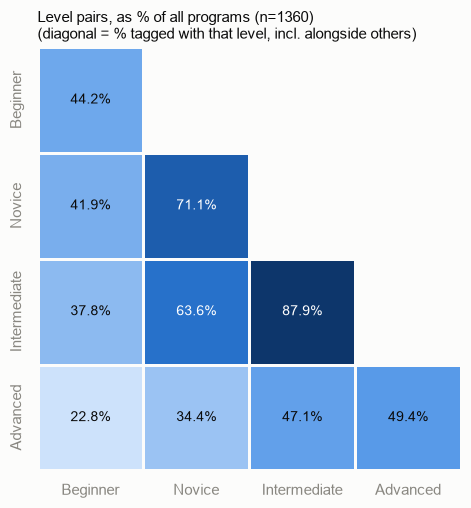

In [28]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
fig.patch.set_facecolor(SURFACE)
sns.heatmap(pct_matrix, mask=mask, annot=annot, fmt='', cmap=blue_cmap, cbar=False,
            linewidths=2, linecolor=SURFACE, square=True, ax=ax,
            annot_kws={'color': INK, 'fontsize': 10})
ax.set_title(f'Level pairs, as % of all programs (n={N_PROGRAMS})\n(diagonal = % tagged with that level, incl. alongside others)',
              color=INK, fontsize=11, loc='left')
ax.set_xlabel(''); ax.set_ylabel('')
 
# ---- adaptive text color: switch to white on the darkest cells so it stays legible ----
norm = plt.Normalize(vmin=pct_matrix.values.min(), vmax=pct_matrix.values.max())
flat_values = [pct_matrix.values[i, j]
               for i in range(pct_matrix.shape[0]) for j in range(pct_matrix.shape[1])
               if not mask[i, j]]
for text, value in zip(ax.texts, flat_values):
    r, g, b, _ = blue_cmap(norm(value))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b   # perceived brightness of the cell color
    text.set_color(TEXT_LIGHT if luminance < 0.5 else INK)
 

# Relationships between different goals

In [29]:
def parse_set(s):
    if pd.isna(s):
        return []
    try:
        return sorted(ast.literal_eval(s))
    except Exception:
        return [x.strip(" '\"") for x in s.strip('{}').split(',') if x.strip()]
 
df['goal_list'] = df['goal'].apply(parse_set)
GOAL_ORDER = list(df['goal_list'].explode().unique())

In [31]:
# ---- 1. long table: one row per (program, level) ----
long = (
    df[['goal_list']]
    .reset_index()                      # keep original row id as the join key
    .rename(columns={'index': 'program_id'})
    .explode('goal_list')
    .rename(columns={'goal_list': 'goal'})
)

In [32]:
long

,program_id,goal
0,0,Bodybuilding
0,0,Powerbuilding
1,1,Bodybuilding
1,1,Powerbuilding
2,2,Bodybuilding
...,...,...
1358,1358,Bodybuilding
1358,1358,Muscle & Sculpting
1359,1359,Athletics
1359,1359,Bodybuilding


In [33]:
# ---- 2. self-join on program_id: every level a program has, paired with every level it has (incl. itself) ----
pairs = long.merge(long, on='program_id', suffixes=('_a', '_b'))

In [34]:
pairs

,program_id,goal_a,goal_b
0,0,Bodybuilding,Bodybuilding
1,0,Bodybuilding,Powerbuilding
2,0,Powerbuilding,Bodybuilding
3,0,Powerbuilding,Powerbuilding
4,1,Bodybuilding,Bodybuilding
...,...,...,...
13109,1359,Bodybuilding,Bodybuilding
13110,1359,Bodybuilding,Muscle & Sculpting
13111,1359,Muscle & Sculpting,Athletics
13112,1359,Muscle & Sculpting,Bodybuilding


In [38]:
# ---- 3. count occurrences of each (level_a, level_b) pair -> pivot into a matrix ----
matrix = (
    pd.crosstab(pairs['goal_a'], pairs['goal_b'])
    .reindex(index=GOAL_ORDER, columns=GOAL_ORDER)
    .fillna(0).astype(int)
)

In [40]:
matrix

goal_b,Bodybuilding,Powerbuilding,Muscle & Sculpting,Powerlifting,Athletics,Bodyweight Fitness,Olympic Weightlifting
goal_a,,,,,,,
Bodybuilding,1132,602,604,392,390,206,45
Powerbuilding,602,715,340,372,263,145,43
Muscle & Sculpting,604,340,691,221,290,178,31
Powerlifting,392,372,221,467,182,102,34
Athletics,390,263,290,182,483,151,37
Bodyweight Fitness,206,145,178,102,151,258,32
Olympic Weightlifting,45,43,31,34,37,32,48


In [39]:
N_PROGRAMS = len(df)

In [41]:
pct_matrix = matrix / N_PROGRAMS * 100

In [43]:
print('single-level programs (no co-occurrence at all):', (df['goal_list'].str.len() == 1).sum())
 

single-level programs (no co-occurrence at all): 251


In [44]:
# ---- plot: mask the upper triangle since the matrix is symmetric ----
BLUE_SEQ = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
            '#3987e5','#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']
blue_cmap = mcolors.LinearSegmentedColormap.from_list('blue_seq', BLUE_SEQ)
INK, INK_SECONDARY, INK_MUTED, GRID, SURFACE = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#fcfcfb'
TEXT_LIGHT = '#ffffff'
 
sns.set_theme(style='white', rc={
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'text.color': INK, 'axes.labelcolor': INK_SECONDARY,
    'xtick.color': INK_MUTED, 'ytick.color': INK_MUTED, 'font.family': 'sans-serif',
})

In [45]:
mask = np.triu(np.ones_like(matrix, dtype=bool), k=1)  # hide the mirrored upper half, keep the diagonal

In [46]:
annot = pct_matrix.round(1).astype(str) + '%'

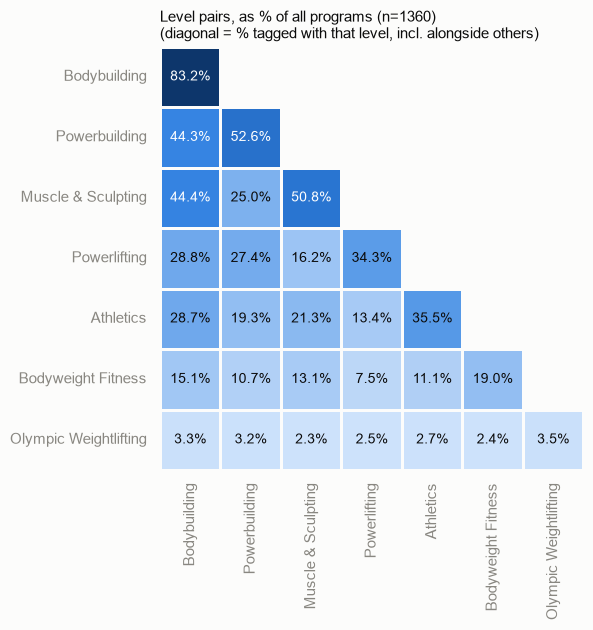

In [47]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
fig.patch.set_facecolor(SURFACE)
sns.heatmap(pct_matrix, mask=mask, annot=annot, fmt='', cmap=blue_cmap, cbar=False,
            linewidths=2, linecolor=SURFACE, square=True, ax=ax,
            annot_kws={'color': INK, 'fontsize': 10})
ax.set_title(f'Level pairs, as % of all programs (n={N_PROGRAMS})\n(diagonal = % tagged with that goal, incl. alongside others)',
              color=INK, fontsize=11, loc='left')
ax.set_xlabel(''); ax.set_ylabel('')
 
# ---- adaptive text color: switch to white on the darkest cells so it stays legible ----
norm = plt.Normalize(vmin=pct_matrix.values.min(), vmax=pct_matrix.values.max())
flat_values = [pct_matrix.values[i, j]
               for i in range(pct_matrix.shape[0]) for j in range(pct_matrix.shape[1])
               if not mask[i, j]]
for text, value in zip(ax.texts, flat_values):
    r, g, b, _ = blue_cmap(norm(value))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b   # perceived brightness of the cell color
    text.set_color(TEXT_LIGHT if luminance < 0.5 else INK)
 

# Relationships between goals and levels

In [48]:
df

,title,description,level,goal,equipment,program_length_weeks,time_per_workout,total_exercises,program_length_days,average_intensity,level_list,goal_list
0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{'Advanced', 'Intermediate', 'Beginner', 'Novi...","{'Powerbuilding', 'Bodybuilding'}",Full Gym,7,90,140,35,8.40,"[Advanced, Beginner, Intermediate, Novice]","[Bodybuilding, Powerbuilding]"
1,Rampage,Pack on muscle and gain strength through this ...,"{'Advanced', 'Intermediate'}","{'Powerbuilding', 'Bodybuilding'}",Full Gym,18,70,558,108,8.51,"[Advanced, Intermediate]","[Bodybuilding, Powerbuilding]"
2,Fitness King Powerbuild 101,To gain strength while building aesthetic musc...,"{'Advanced', 'Intermediate'}","{'Powerbuilding', 'Bodybuilding'}",Full Gym,11,160,324,56,7.62,"[Advanced, Intermediate]","[Bodybuilding, Powerbuilding]"
3,Larry's Modified Bullmastiff Powerbuilding Pro...,All credit to Alex. You can find his original ...,"{'Intermediate', 'Beginner', 'Novice'}","{'Muscle & Sculpting', 'Powerlifting', 'Powerb...",Full Gym,9,70,342,54,7.30,"[Beginner, Intermediate, Novice]","[Bodybuilding, Muscle & Sculpting, Powerbuildi..."
4,Metallicdpas PPL (Reddit),"Metallicdpas’ PPL targeted towards beginners, ...","{'Intermediate', 'Beginner', 'Novice'}","{'Muscle & Sculpting', 'Bodybuilding', 'Athlet...",Garage Gym,6,60,216,36,7.72,"[Beginner, Intermediate, Novice]","[Athletics, Bodybuilding, Muscle & Sculpting]"
...,...,...,...,...,...,...,...,...,...,...,...,...
1355,PPL x Arnold (0),The Arnold workout split is known for its high...,"{'Intermediate', 'Novice'}","{'Muscle & Sculpting', 'Bodybuilding'}",Full Gym,12,90,384,60,7.95,"[Intermediate, Novice]","[Bodybuilding, Muscle & Sculpting]"
1356,PPL x Arnold (1),Ppl x Arnold split to get massive,"{'Advanced', 'Intermediate', 'Beginner', 'Novi...","{'Bodybuilding', 'Athletics'}",Full Gym,8,60,360,56,7.89,"[Advanced, Beginner, Intermediate, Novice]","[Athletics, Bodybuilding]"
1357,3 Day Baki Grappler Condensed Conjugate (0),This program is designed for martial artists w...,"{'Beginner', 'Novice'}",{'Athletics'},Garage Gym,4,60,44,12,6.73,"[Beginner, Novice]",[Athletics]
1358,3 Day Baki Grappler Condensed Conjugate (1),Who Is This For?\nMartial artists who train BJ...,"{'Advanced', 'Intermediate'}","{'Muscle & Sculpting', 'Bodybuilding', 'Athlet...",Garage Gym,4,60,48,12,9.00,"[Advanced, Intermediate]","[Athletics, Bodybuilding, Muscle & Sculpting]"


In [67]:
long =  (df[['level_list','goal_list']]
    .rename(columns={'index': 'program_id'})
    .explode('goal_list').explode('level_list')
    .rename(columns={'goal_list': 'goal', 'level_list':'level'})
    .reset_index(drop=True))

In [56]:
N_PROGRAMS = len(df)

In [68]:
long

,level,goal
0,Advanced,Bodybuilding
1,Beginner,Bodybuilding
2,Intermediate,Bodybuilding
3,Novice,Bodybuilding
4,Advanced,Powerbuilding
...,...,...
10253,Intermediate,Athletics
10254,Advanced,Bodybuilding
10255,Intermediate,Bodybuilding
10256,Advanced,Muscle & Sculpting


In [69]:
pd.crosstab(long['level'], long['goal'])

goal,Athletics,Bodybuilding,Bodyweight Fitness,Muscle & Sculpting,Olympic Weightlifting,Powerbuilding,Powerlifting
level,,,,,,,
Advanced,263,594,132,369,33,400,269
Beginner,277,506,160,345,25,325,229
Intermediate,432,1019,224,627,41,675,431
Novice,379,832,205,546,31,538,351


In [70]:
# ---- 3. count occurrences of each (level_a, level_b) pair -> pivot into a matrix ----
matrix = (
    pd.crosstab(long['level'], long['goal'])
    .reindex(index=LEVEL_ORDER, columns=GOAL_ORDER)
    .fillna(0).astype(int)
)

In [71]:
pct_matrix = matrix / N_PROGRAMS * 100

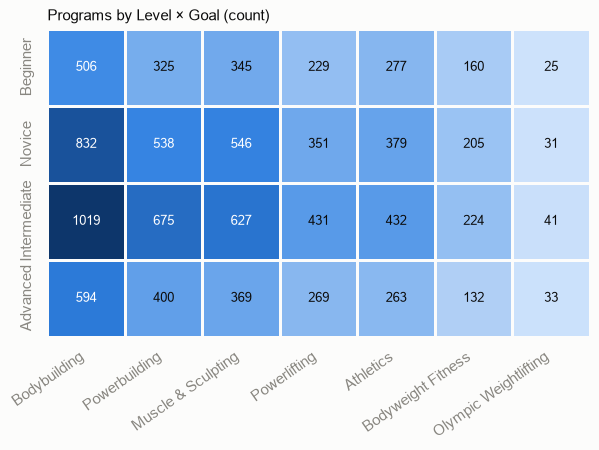

In [81]:
# (1) raw co-occurrence heatmap
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap=blue_cmap, cbar=False,
            linewidths=2, linecolor=SURFACE, ax=ax, annot_kws={'color': INK, 'fontsize': 9})
ax.set_title('Programs by Level × Goal (count)', color=INK, fontsize=11, loc='left')
ax.set_xlabel(''); ax.set_ylabel('')
ax.tick_params(axis='x', rotation=35)
for lbl in ax.get_xticklabels():
    lbl.set_ha('right')

norm = plt.Normalize(vmin=pct_matrix.values.min(), vmax=pct_matrix.values.max())
flat_values = [pct_matrix.values[i, j]
               for i in range(pct_matrix.shape[0]) for j in range(pct_matrix.shape[1])
               ]
for text, value in zip(ax.texts, flat_values):
    r, g, b, _ = blue_cmap(norm(value))
    luminance = 0.299 * r + 0.587 * g + 0.114 * b   # perceived brightness of the cell color
    text.set_color(TEXT_LIGHT if luminance < 0.5 else INK)
 

# In the near future: relationships between workout day types, levels and goals